In [9]:
pip install langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [11]:
class MyState(TypedDict):
    input: str
    output: str

In [26]:
MyState(input="Hello", output="HELLO")

{'input': 'Hello', 'output': 'HELLO'}

#####   Custom Node

In [42]:
def process_input(state: MyState) -> MyState:
    output = state["input"].upper()
    return {'output': output}

In [43]:
state = {'input':'Hello', 'output':''}
process_input(state)

{'output': 'HELLO'}

In [62]:
def add_prefix(state: MyState) -> MyState:
    txt = "Prefix: " + state["output"]
    return {'output': txt}

In [63]:
def add_Suffix(state: MyState) -> MyState:
   txt = state["output"] + " Suffix"
   return {'output': txt}

In [66]:
add_Suffix(add_prefix(process_input(state)))

{'output': 'Prefix: HELLO Suffix'}

In [69]:
def create_graph() -> StateGraph:
    graph = StateGraph(MyState)
    # Add nodes to the graph
    graph.add_node("process_input", process_input)
    graph.add_node("add_prefix", add_prefix)
    graph.add_node("add_Suffix", add_Suffix)
    
    # Add edges to define the flow of the graph
    graph.add_edge(START, "process_input")
    graph.add_edge("process_input", "add_prefix")
    graph.add_edge("add_prefix", "add_Suffix")
    graph.add_edge("add_Suffix", END)
    
    graph = graph.compile()
    return graph

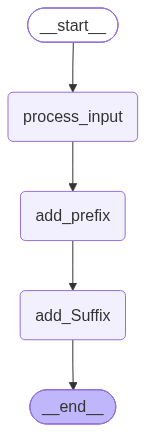

In [70]:
graph = create_graph()
graph

In [72]:
graph.invoke({'input': 'Hello', 'output': ''})

{'input': 'Hello', 'output': 'Prefix: HELLO Suffix'}